# 🧠 Notebook 2 — Model Training & Cross-Validation

**Project**: Multi-Step ECG Time-Series Forecasting using Stacked LSTM  
**Author**: Prabhas Avvaru  

---

## Objective
Train and evaluate multiple recurrent neural network architectures (LSTM, GRU)
using 5-fold cross-validation with early stopping. Compare single-layer vs
stacked architectures and MSE vs MAE loss functions.

### Models Evaluated
| # | Architecture | Layers | Hidden | Params |
|---|---|---|---|---|
| 1 | LSTM-1 layer  | 1 | 64 | ~17K |
| 2 | LSTM-2 layers | 2 | 64→32 | ~52K |
| 3 | GRU-1 layer   | 1 | 64 | ~13K |
| 4 | GRU-2 layers  | 2 | 64→32 | ~40K |

---

In [35]:
# ── Imports ──────────────────────────────────────────────────
import sys, os, warnings, time
sys.path.insert(0, os.path.abspath('..'))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from src.data import prepare_data
from src.models import model_factory, model_summary, count_parameters
from src.training import set_seeds, cross_validate
from src.metrics import format_results_table, paired_ttest

# ── Style ────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='deep', font_scale=1.1)
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'figure.dpi': 120,
    'savefig.bbox': 'tight',
    'savefig.dpi': 150,
})

FIGURES = '../figures'
DATA_PATH = '../data/ecg_raw.csv'

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch {torch.__version__} — device: {DEVICE}')
print('Setup complete ✓')

PyTorch 2.8.0 — device: cpu
Setup complete ✓


## 1 · Configuration

In [36]:
# ── Hyper-parameters ─────────────────────────────────────────
CONFIG = {
    'seed': 42,
    'n_splits': 5,
    'epochs': 100,
    'batch_size': 8,
    'lr': 1e-3,
    'patience': 10,
}

# ── Model configurations ─────────────────────────────────────
MODEL_CONFIGS = [
    {'arch': 'lstm', 'num_layers': 1, 'hidden_dim': 64, 'dropout': 0.0},
    {'arch': 'lstm', 'num_layers': 2, 'hidden_dim': 64, 'dropout': 0.2},
    {'arch': 'gru',  'num_layers': 1, 'hidden_dim': 64, 'dropout': 0.0},
    {'arch': 'gru',  'num_layers': 2, 'hidden_dim': 64, 'dropout': 0.2},
]

print('Experiment Configuration')
print('=' * 40)
for k, v in CONFIG.items():
    print(f'  {k:15s}: {v}')

Experiment Configuration
  seed           : 42
  n_splits       : 5
  epochs         : 100
  batch_size     : 8
  lr             : 0.001
  patience       : 10


## 2 · Model Architectures

In [37]:
# ── Print model summaries ──
for cfg in MODEL_CONFIGS:
    m = model_factory(**cfg)
    print(model_summary(m))
    print('-' * 50)

Model : LSTM-1 layer
Params: 19,009

  lstm.weight_ih_l0                                     [256, 8]
  lstm.weight_hh_l0                                    [256, 64]
  lstm.bias_ih_l0                                          [256]
  lstm.bias_hh_l0                                          [256]
  fc.weight                                              [1, 64]
  fc.bias                                                    [1]
--------------------------------------------------
Model : LSTM-2 layers
Params: 52,289

  lstm.weight_ih_l0                                     [256, 8]
  lstm.weight_hh_l0                                    [256, 64]
  lstm.bias_ih_l0                                          [256]
  lstm.bias_hh_l0                                          [256]
  lstm.weight_ih_l1                                    [256, 64]
  lstm.weight_hh_l1                                    [256, 64]
  lstm.bias_ih_l1                                          [256]
  lstm.bias_hh_l1            

## 3 · Load Data (After Imputation)

In [38]:
data = prepare_data(DATA_PATH, impute_output13=True)

X_scaled = data['X_scaled']
Y_scaled = data['Y_scaled']
scaler_y = data['scaler_y']

print(f'Patients: {data["n_patients"]}')
print(f'X_scaled: {X_scaled.shape}')
print(f'Y_scaled: {Y_scaled.shape}')
print(f'\nOutlier info: {data["outlier_info"]["fill_value"]:.2f} (fill value)')

Patients: 65
X_scaled: (65, 17, 8)
Y_scaled: (65, 17, 1)

Outlier info: 12.93 (fill value)


## 4 · Cross-Validation — MSE Loss

In [39]:
print('Training with MSE Loss')
print('=' * 60)

set_seeds(CONFIG['seed'])
t0 = time.time()

results_mse = cross_validate(
    X_scaled, Y_scaled, scaler_y,
    model_configs=MODEL_CONFIGS,
    loss_fn='mse',
    device=DEVICE,
    **{k: v for k, v in CONFIG.items() if k != 'seed'},
    seed=CONFIG['seed'],
)

elapsed = time.time() - t0
print(f'\nTotal training time: {elapsed:.1f}s')

Training with MSE Loss
  [LSTM-1 layer] Fold 1/5 ... MSE=11.8221  RMSE=3.4383  MAE=2.2011  (100 epochs)
  [LSTM-1 layer] Fold 2/5 ... MSE=10.0374  RMSE=3.1682  MAE=2.3793  (100 epochs)
  [LSTM-1 layer] Fold 3/5 ... MSE=9.6556  RMSE=3.1074  MAE=2.3017  (100 epochs)
  [LSTM-1 layer] Fold 4/5 ... MSE=10.8938  RMSE=3.3006  MAE=2.3755  (100 epochs)
  [LSTM-1 layer] Fold 5/5 ... MSE=15.2407  RMSE=3.9039  MAE=2.9717  (84 epochs)
  [LSTM-2 layers] Fold 1/5 ... MSE=11.4264  RMSE=3.3803  MAE=2.1428  (100 epochs)
  [LSTM-2 layers] Fold 2/5 ... MSE=11.4177  RMSE=3.3790  MAE=2.6369  (69 epochs)
  [LSTM-2 layers] Fold 3/5 ... MSE=11.8111  RMSE=3.4367  MAE=2.6258  (71 epochs)
  [LSTM-2 layers] Fold 4/5 ... MSE=8.7262  RMSE=2.9540  MAE=2.1296  (100 epochs)
  [LSTM-2 layers] Fold 5/5 ... MSE=15.6012  RMSE=3.9498  MAE=2.8964  (69 epochs)
  [GRU-1 layer] Fold 1/5 ... MSE=12.0614  RMSE=3.4730  MAE=2.1081  (100 epochs)
  [GRU-1 layer] Fold 2/5 ... MSE=9.1240  RMSE=3.0206  MAE=2.3086  (100 epochs)
  [GRU-1 

## 5 · Cross-Validation — MAE Loss

In [40]:
print('Training with MAE Loss')
print('=' * 60)

set_seeds(CONFIG['seed'])
t0 = time.time()

results_mae = cross_validate(
    X_scaled, Y_scaled, scaler_y,
    model_configs=MODEL_CONFIGS,
    loss_fn='mae',
    device=DEVICE,
    **{k: v for k, v in CONFIG.items() if k != 'seed'},
    seed=CONFIG['seed'],
)

elapsed = time.time() - t0
print(f'\nTotal training time: {elapsed:.1f}s')

Training with MAE Loss
  [LSTM-1 layer] Fold 1/5 ... MSE=21.1571  RMSE=4.5997  MAE=2.1704  (100 epochs)
  [LSTM-1 layer] Fold 2/5 ... MSE=10.3363  RMSE=3.2150  MAE=2.2988  (79 epochs)
  [LSTM-1 layer] Fold 3/5 ... MSE=10.3226  RMSE=3.2129  MAE=1.9575  (100 epochs)
  [LSTM-1 layer] Fold 4/5 ... MSE=10.4030  RMSE=3.2254  MAE=1.8090  (100 epochs)
  [LSTM-1 layer] Fold 5/5 ... MSE=12.5660  RMSE=3.5449  MAE=2.3517  (100 epochs)
  [LSTM-2 layers] Fold 1/5 ... MSE=27.2291  RMSE=5.2182  MAE=1.9529  (100 epochs)
  [LSTM-2 layers] Fold 2/5 ... MSE=7.4919  RMSE=2.7371  MAE=1.9679  (100 epochs)
  [LSTM-2 layers] Fold 3/5 ... MSE=13.5275  RMSE=3.6780  MAE=1.9079  (100 epochs)
  [LSTM-2 layers] Fold 4/5 ... MSE=11.7830  RMSE=3.4326  MAE=1.9277  (100 epochs)
  [LSTM-2 layers] Fold 5/5 ... MSE=13.1026  RMSE=3.6198  MAE=2.3002  (100 epochs)
  [GRU-1 layer] Fold 1/5 ... MSE=29.5141  RMSE=5.4327  MAE=1.9873  (100 epochs)
  [GRU-1 layer] Fold 2/5 ... MSE=5.0541  RMSE=2.2481  MAE=1.4978  (100 epochs)
  [GR

## 6 · Results Summary

In [41]:
# ── Aggregate per-fold results into a summary table ──
def make_summary(results_dict, loss_label):
    rows = []
    for model_name, folds in results_dict.items():
        mse_vals = [f['MSE'] for f in folds]
        rmse_vals = [f['RMSE'] for f in folds]
        mae_vals = [f['MAE'] for f in folds]
        r2_vals = [f['R²'] for f in folds]
        rows.append({
            'Loss': loss_label,
            'Model': model_name,
            'MSE': np.mean(mse_vals),
            'RMSE': np.mean(rmse_vals),
            'MAE': np.mean(mae_vals),
            'R²': np.mean(r2_vals),
            'MSE (std)': np.std(mse_vals),
        })
    return rows

summary_rows = make_summary(results_mse, 'MSE') + make_summary(results_mae, 'MAE')
summary_df = pd.DataFrame(summary_rows)

# Format for display
display_df = summary_df.copy()
for col in ['MSE', 'RMSE', 'MAE', 'R²', 'MSE (std)']:
    display_df[col] = display_df[col].apply(lambda x: f'{x:.4f}')

print('\n' + '=' * 70)
print('CROSS-VALIDATION RESULTS SUMMARY (After Imputation)')
print('=' * 70)
display(display_df)


CROSS-VALIDATION RESULTS SUMMARY (After Imputation)


,Loss,Model,MSE,RMSE,MAE,R²,MSE (std)
0,MSE,LSTM-1 layer,11.5299,3.3837,2.4458,0.6990,2.0000
1,MSE,LSTM-2 layers,11.7965,3.4200,2.4863,0.6961,2.1992
2,MSE,GRU-1 layer,10.8860,3.2821,2.3491,0.7139,2.2992
3,MSE,GRU-2 layers,9.2196,3.0187,2.1172,0.7501,2.0021
4,MAE,LSTM-1 layer,12.9570,3.5596,2.1175,0.6380,4.1887
5,MAE,LSTM-2 layers,14.6268,3.7371,2.0113,0.5769,6.6535
6,MAE,GRU-1 layer,14.9551,3.7282,1.7863,0.5583,8.0772
7,MAE,GRU-2 layers,14.3746,3.6287,1.7399,0.5683,9.0182


## 7 · Training Loss Curves

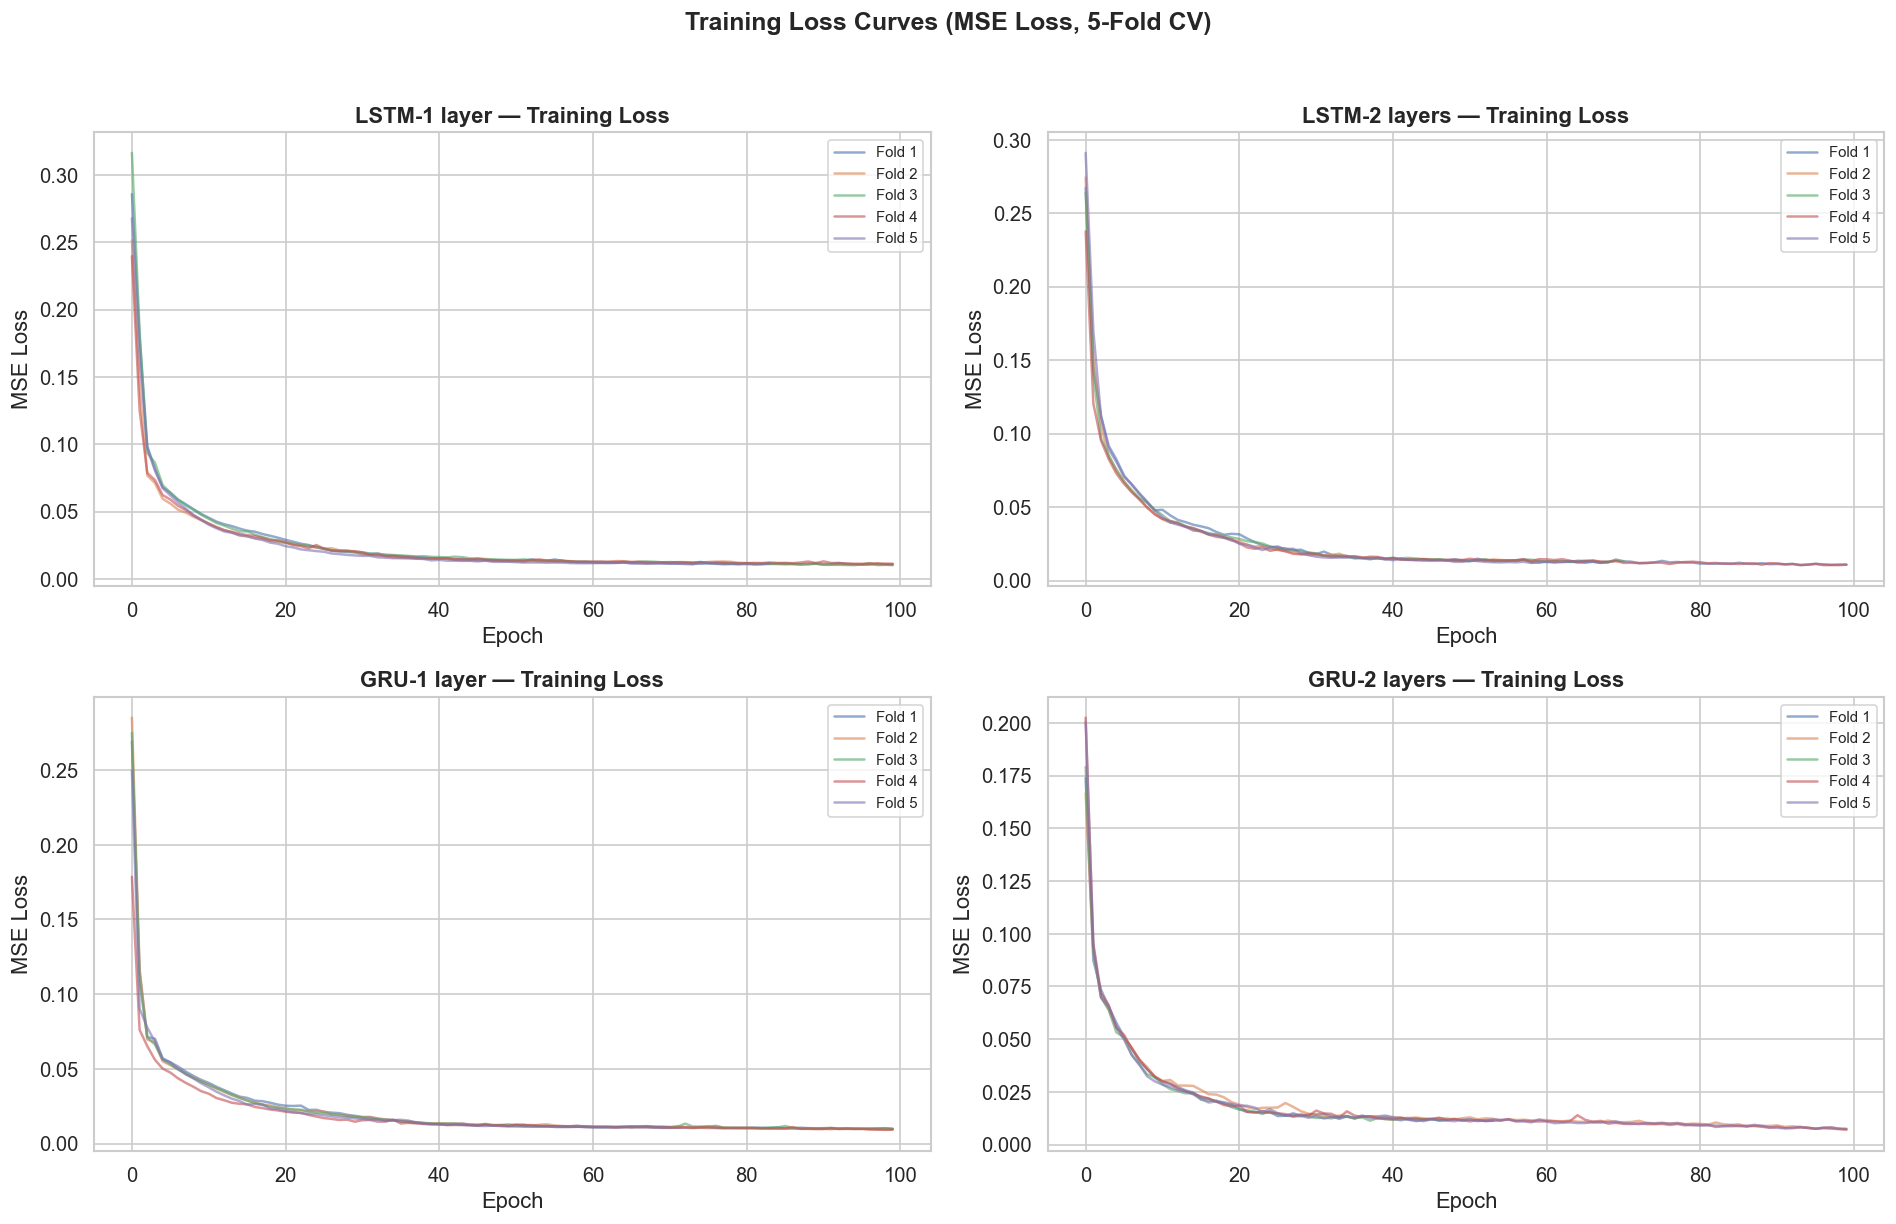

In [42]:
# ── Plot training loss curves (MSE experiments) ──
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
model_names = list(results_mse.keys())

for idx, (model_name, folds) in enumerate(results_mse.items()):
    ax = axes[idx // 2, idx % 2]
    for fold_data in folds:
        ax.plot(fold_data['loss_history'], alpha=0.6,
                label=f'Fold {fold_data["Fold"]}')
    ax.set_title(f'{model_name} — Training Loss', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend(fontsize=9, loc='upper right')

fig.suptitle('Training Loss Curves (MSE Loss, 5-Fold CV)', fontsize=15, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig(f'{FIGURES}/training_loss_curves.png')
plt.show()

## 8 · Model Comparison Bar Chart

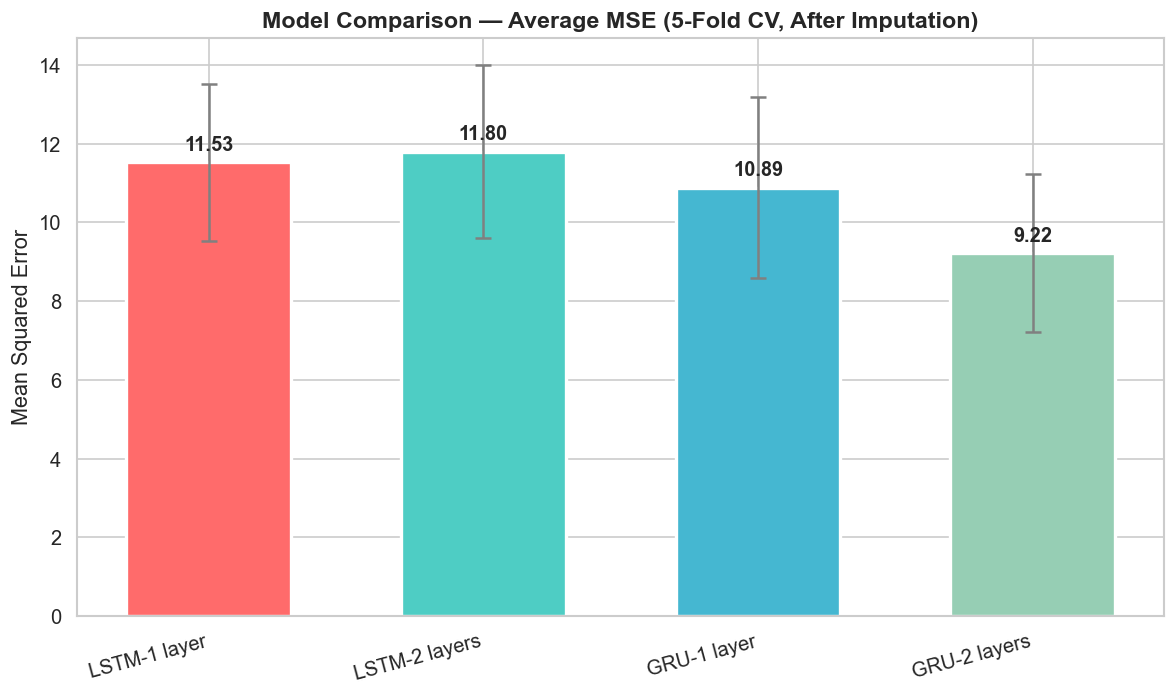

In [43]:
# ── Bar chart: MSE by model (MSE loss only) ──
mse_summary = [r for r in summary_rows if r['Loss'] == 'MSE']
mse_df = pd.DataFrame(mse_summary)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

bars = ax.bar(mse_df['Model'], mse_df['MSE'], color=colors,
              edgecolor='white', linewidth=2, width=0.6)

# Error bars from std
ax.errorbar(mse_df['Model'], mse_df['MSE'], yerr=mse_df['MSE (std)'],
            fmt='none', ecolor='gray', capsize=5, capthick=1.5)

for bar, val in zip(bars, mse_df['MSE']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.2f}', ha='center', fontweight='bold', fontsize=12)

ax.set_ylabel('Mean Squared Error', fontsize=13)
ax.set_title('Model Comparison — Average MSE (5-Fold CV, After Imputation)',
             fontweight='bold', fontsize=14)
ax.set_xticklabels(mse_df['Model'], rotation=15, ha='right')

fig.tight_layout()
fig.savefig(f'{FIGURES}/model_comparison_mse.png')
plt.show()

## 9 · Prediction vs Actual (Sample Patient)

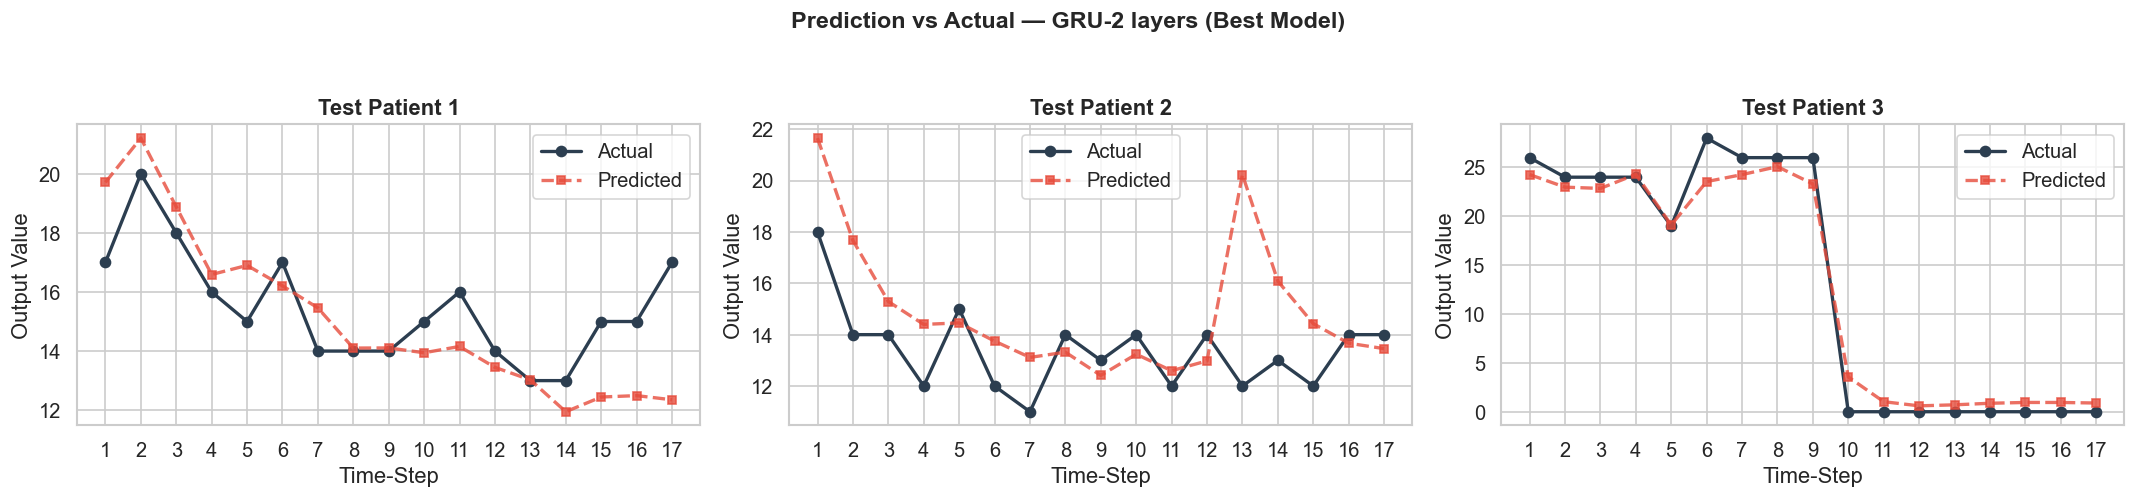

In [44]:
# ── Plot predictions vs actuals for the best model (last fold) ──
best_model_name = min(results_mse, key=lambda k: np.mean([f['MSE'] for f in results_mse[k]]))
best_fold = results_mse[best_model_name][-1]  # last fold

preds = best_fold['predictions']
actuals = best_fold['actuals']

# Pick 3 patients from the test set
n_show = min(3, preds.shape[0])

fig, axes = plt.subplots(1, n_show, figsize=(6*n_show, 4))
if n_show == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    t = np.arange(1, 18)
    ax.plot(t, actuals[i, :, 0], 'o-', color='#2C3E50', linewidth=2,
            markersize=6, label='Actual')
    ax.plot(t, preds[i, :, 0], 's--', color='#E74C3C', linewidth=2,
            markersize=5, alpha=0.8, label='Predicted')
    ax.set_xlabel('Time-Step')
    ax.set_ylabel('Output Value')
    ax.set_title(f'Test Patient {i+1}', fontweight='bold')
    ax.legend()
    ax.set_xticks(t)

fig.suptitle(f'Prediction vs Actual — {best_model_name} (Best Model)',
             fontsize=14, fontweight='bold', y=1.04)
fig.tight_layout()
fig.savefig(f'{FIGURES}/prediction_vs_actual.png')
plt.show()

## 10 · Save Results for Downstream Notebooks

In [45]:
import pickle

results_bundle = {
    'config': CONFIG,
    'model_configs': MODEL_CONFIGS,
    'results_mse': {k: [{kk: vv for kk, vv in f.items() if kk not in ('predictions', 'actuals')} for f in v]
                    for k, v in results_mse.items()},
    'results_mae': {k: [{kk: vv for kk, vv in f.items() if kk not in ('predictions', 'actuals')} for f in v]
                    for k, v in results_mae.items()},
    'summary_df': summary_df,
}

with open('../data/training_results.pkl', 'wb') as f:
    pickle.dump(results_bundle, f)

print('Results saved to data/training_results.pkl ✓')
print(f'\nBest model (MSE loss): {best_model_name}')
best_mse = np.mean([f["MSE"] for f in results_mse[best_model_name]])
print(f'Average MSE: {best_mse:.4f}')

Results saved to data/training_results.pkl ✓

Best model (MSE loss): GRU-2 layers
Average MSE: 9.2196


## Summary

| Aspect | Detail |
|---|---|
| Framework | PyTorch |
| Validation | 5-Fold Cross-Validation |
| Models | LSTM (1L, 2L), GRU (1L, 2L) |
| Loss functions | MSE, MAE |
| Early stopping | patience=10, restore best weights |
| Regularisation | Dropout (0.2 for 2-layer models) |

**Next** → [Notebook 3: Results & Analysis](./03_Results_and_Analysis.ipynb)